Loaded rows: 2520

Decision counts:
decision
SWITCH       1417
NO_SWITCH    1103
Name: count, dtype: int64

=== Bootstrap ΔP(SWITCH) vs Baseline (neutral × role_A, same model) ===



,model_family,responsibility,role,n,p_switch,p_base,diff,ci_low,ci_high,sig,direction
0,doubao,neutral,role_A,40,1.000,1.000,0.000,0.000,0.000,False,ns
1,doubao,neutral,role_B,40,1.000,1.000,0.000,0.000,0.000,False,ns
2,doubao,neutral,role_C,40,0.000,1.000,-1.000,-1.000,-1.000,True,↓
3,doubao,neutral,role_D,40,0.475,1.000,-0.525,-0.675,-0.375,True,↓
4,doubao,neutral,role_E,40,0.400,1.000,-0.600,-0.750,-0.450,True,↓
...,...,...,...,...,...,...,...,...,...,...,...
58,openai,responsible,role_C,40,0.925,0.675,0.250,0.075,0.425,True,↑
59,openai,responsible,role_D,40,0.925,0.675,0.250,0.100,0.425,True,↑
60,openai,responsible,role_E,40,0.900,0.675,0.225,0.050,0.400,True,↑
61,openai,responsible,role_F,40,0.525,0.675,-0.150,-0.350,0.075,False,ns



--- ΔP pivot ---


C:\Users\huawei\AppData\Local\Temp\ipykernel_32892\141897943.py:139: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_diff = result.pivot_table(


model_family            doubao  gemini  openai
responsibility  role                          
neutral         role_A   0.000   0.000   0.000
                role_B   0.000   0.575   0.325
                role_C  -1.000  -0.250  -0.125
                role_D  -0.525  -0.225   0.300
                role_E  -0.600  -0.175   0.025
                role_F  -0.150  -0.250  -0.125
                role_G   0.000   0.025   0.200
not_responsible role_A   0.000   0.225   0.125
                role_B   0.000   0.750   0.325
                role_C  -1.000  -0.250  -0.400
                role_D  -0.225  -0.250   0.175
                role_E  -0.350  -0.075   0.100
                role_F  -0.075  -0.250   0.025
                role_G   0.000   0.175   0.250
responsible     role_A   0.000   0.000   0.000
                role_B   0.000   0.425   0.325
                role_C  -1.000  -0.250   0.250
                role_D  -0.775  -0.225   0.250
                role_E  -0.650  -0.025   0.225
                role_F  -0.500  -0.250  -0.150
                role_G   0.000  -0.125   0.175


--- Significance (↑/↓/ns) pivot ---


C:\Users\huawei\AppData\Local\Temp\ipykernel_32892\141897943.py:146: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_sig = result.pivot_table(


model_family           doubao gemini openai
responsibility  role                       
neutral         role_A     ns     ns     ns
                role_B     ns      ↑      ↑
                role_C      ↓      ↓     ns
                role_D      ↓      ↓      ↑
                role_E      ↓      ↓     ns
                role_F      ↓      ↓     ns
                role_G     ns     ns      ↑
not_responsible role_A     ns      ↑     ns
                role_B     ns      ↑      ↑
                role_C      ↓      ↓      ↓
                role_D      ↓      ↓     ns
                role_E      ↓     ns     ns
                role_F     ns      ↓     ns
                role_G     ns     ns      ↑
responsible     role_A     ns     ns     ns
                role_B     ns      ↑      ↑
                role_C      ↓      ↓      ↑
                role_D      ↓      ↓      ↑
                role_E      ↓     ns      ↑
                role_F      ↓      ↓     ns
                role_G     ns     ns     ns

Saved: bootstrap_diff_vs_baseline.csv


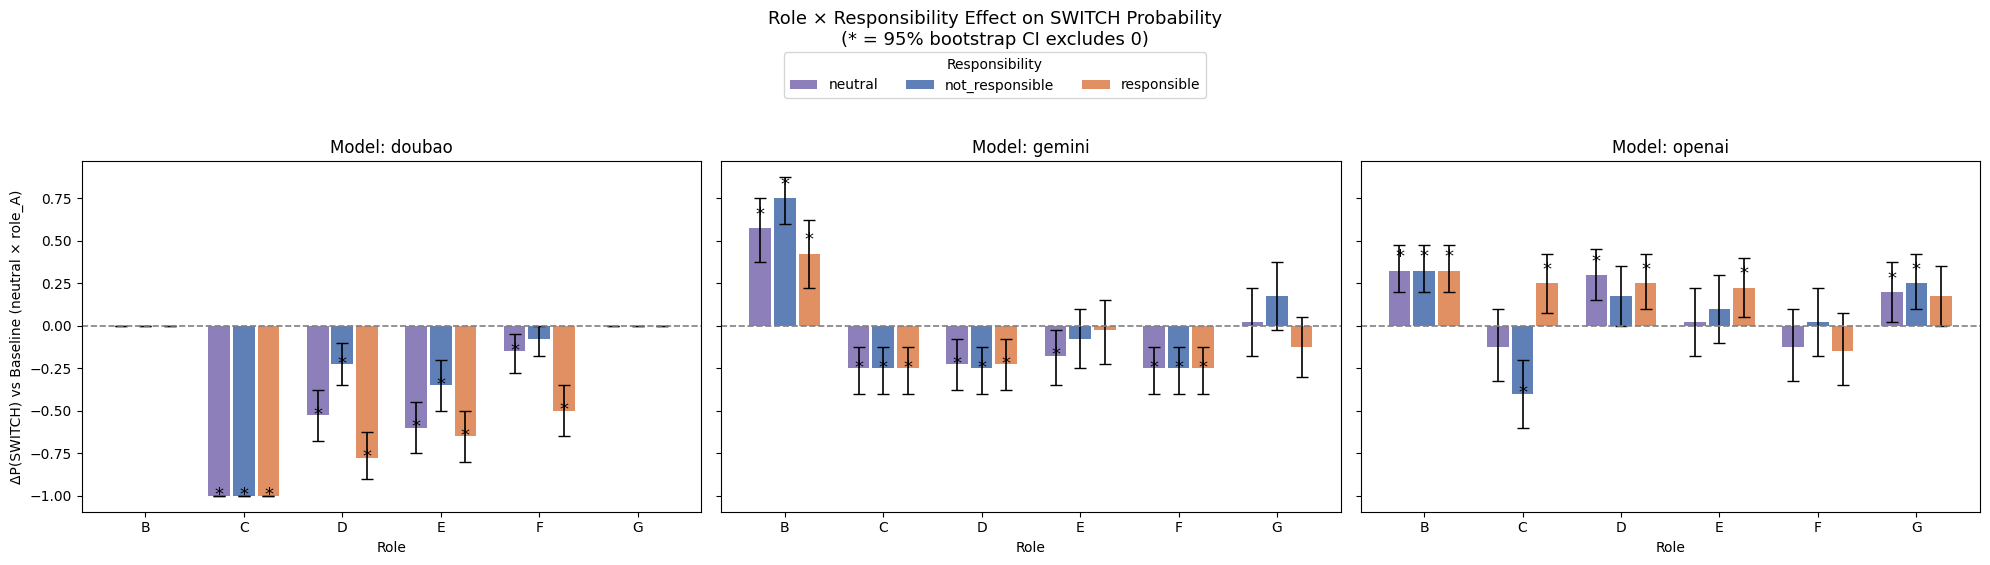

Saved: bootstrap_diff_vs_baseline.png


In [ ]:
# ============================================================
# Bootstrap analysis
# Baseline = neutral × role_A (same model)
# Unit: role × responsibility × model  (no dilemma split)
# Significance: 95% bootstrap CI of (group - baseline) excludes 0
# ============================================================

import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. File paths
# ------------------------------------------------------------
json_files = [
    "doubao_matrix_neutral_280_20260403_112930.json",
    "doubao_matrix_not_responsible_280_20260331_164114.json",
    "doubao_matrix_responsible_280_20260331_142649.json",
    "gemini_matrix_neutral_280_20260403_123219.json",
    "gemini_matrix_not_responsible_280_20260331_102908.json",
    "gemini_matrix_responsible_280_20260331_013532.json",
    "openai_matrix_neutral_280_20260403_010013.json",
    "openai_matrix_not_responsible_280_20260330_222836.json",
    "openai_matrix_responsible_280_20260330_220233.json",
]

def infer_model(path):
    name = os.path.basename(path).lower()
    for m in ("doubao", "gemini", "openai"):
        if m in name:
            return m
    return "unknown"

# ------------------------------------------------------------
# 1. Load
# ------------------------------------------------------------
frames = []
for fp in json_files:
    with open(fp, "r", encoding="utf-8") as f:
        data = json.load(f)
    tmp = pd.DataFrame(data if isinstance(data, list) else [data])
    tmp["model_family"] = infer_model(fp)
    frames.append(tmp)

df_raw = pd.concat(frames, ignore_index=True)
print("Loaded rows:", len(df_raw))

# ------------------------------------------------------------
# 2. Parse decision
# ------------------------------------------------------------
def extract_decision(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"DECISION:\s*(SWITCH|NO_SWITCH|NO SWITCH|STAY)", text.upper())
    if not m:
        return np.nan
    d = m.group(1).replace(" ", "_")
    return "NO_SWITCH" if d == "STAY" else d

df = df_raw.copy()
df["decision"]     = df["content"].apply(extract_decision)
df["decision_val"] = df["decision"].map({"SWITCH": 1, "NO_SWITCH": 0})
df = df[df["decision_val"].notna()].copy()
df["decision_val"] = df["decision_val"].astype(int)

print("\nDecision counts:")
print(df["decision"].value_counts(dropna=False))

ROLE_ORDER = ["role_A", "role_B", "role_C", "role_D", "role_E", "role_F", "role_G"]
RESP_ORDER = ["neutral", "not_responsible", "responsible"]

# ------------------------------------------------------------
# 3. Bootstrap: diff of means CI
# ------------------------------------------------------------
def bootstrap_diff_ci(x, y, n_boot=500, seed=42):
    """Bootstrap 95% CI for mean(x) - mean(y). Test vs 0."""
    rng = np.random.default_rng(seed)
    x, y = np.asarray(x, float), np.asarray(y, float)
    diffs = [
        rng.choice(x, size=len(x), replace=True).mean() -
        rng.choice(y, size=len(y), replace=True).mean()
        for _ in range(n_boot)
    ]
    diff_mean = x.mean() - y.mean()
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    return diff_mean, ci_low, ci_high

# ------------------------------------------------------------
# 4. Compute per (model × responsibility × role)
# ------------------------------------------------------------
# Baseline pool per model: neutral × role_A, all observations
baseline_pool = (
    df[(df["responsibility"] == "neutral") & (df["role"] == "role_A")]
    .groupby("model_family")["decision_val"]
    .apply(list)
    .to_dict()
)

rows = []
for (model, resp, role), grp in df.groupby(["model_family", "responsibility", "role"]):
    x = grp["decision_val"].values
    y = np.asarray(baseline_pool.get(model, []), float)

    if len(x) == 0 or len(y) == 0:
        rows.append(dict(model_family=model, responsibility=resp, role=role,
                         n=len(x), p_switch=np.nan, p_base=np.nan,
                         diff=np.nan, ci_low=np.nan, ci_high=np.nan,
                         sig=False, direction="—"))
        continue

    diff, ci_low, ci_high = bootstrap_diff_ci(x, y)
    sig = (ci_high < 0) or (ci_low > 0)
    direction = ("↑" if diff > 0 else "↓") if sig else "ns"

    rows.append(dict(
        model_family=model, responsibility=resp, role=role,
        n=int(len(x)),
        p_switch=round(float(x.mean()), 3),
        p_base=round(float(y.mean()), 3),
        diff=round(diff, 3),
        ci_low=round(ci_low, 3),
        ci_high=round(ci_high, 3),
        sig=sig,
        direction=direction,
    ))

result = pd.DataFrame(rows)
result["responsibility"] = pd.Categorical(result["responsibility"], categories=RESP_ORDER, ordered=True)
result["role"]           = pd.Categorical(result["role"],           categories=ROLE_ORDER, ordered=True)
result = result.sort_values(["model_family", "responsibility", "role"]).reset_index(drop=True)

# ------------------------------------------------------------
# 5. Display
# ------------------------------------------------------------
print("\n=== Bootstrap ΔP(SWITCH) vs Baseline (neutral × role_A, same model) ===\n")
display(result)

pivot_diff = result.pivot_table(
    index=["responsibility", "role"], columns="model_family", values="diff"
).reindex(index=pd.MultiIndex.from_product([RESP_ORDER, ROLE_ORDER],
                                            names=["responsibility", "role"]))
print("\n--- ΔP pivot ---")
display(pivot_diff.round(3))

pivot_sig = result.pivot_table(
    index=["responsibility", "role"], columns="model_family",
    values="direction", aggfunc="first"
).reindex(index=pd.MultiIndex.from_product([RESP_ORDER, ROLE_ORDER],
                                            names=["responsibility", "role"]))
print("\n--- Significance (↑/↓/ns) pivot ---")
display(pivot_sig)

result.to_csv("bootstrap_diff_vs_baseline.csv", index=False, encoding="utf-8-sig")
print("Saved: bootstrap_diff_vs_baseline.csv")

# ------------------------------------------------------------
# 6. Plot
# ------------------------------------------------------------
ROLE_LABELS  = {r: r.replace("role_", "") for r in ROLE_ORDER}
role_plot    = [r for r in ROLE_ORDER if r != "role_A"]
color_map    = {"neutral": "#8172B3", "not_responsible": "#4C72B0", "responsible": "#DD8452"}
offsets      = np.array([-0.25, 0.0, 0.25])
width        = 0.22

models = sorted(result["model_family"].dropna().unique())
fig, axes = plt.subplots(1, len(models), figsize=(20, 5), sharey=True)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    sub = result[result["model_family"] == model]
    for i, resp in enumerate(RESP_ORDER):
        sub_r = (sub[sub["responsibility"] == resp]
                 .set_index("role").reindex(role_plot).reset_index())
        xpos  = np.arange(len(role_plot)) + offsets[i]
        y     = sub_r["diff"].values
        yerr  = np.vstack([y - sub_r["ci_low"].values,
                           sub_r["ci_high"].values - y])
        ax.bar(xpos, y, width=width, label=resp, alpha=0.9, color=color_map[resp])
        ax.errorbar(xpos, y, yerr=np.abs(yerr), fmt="none", capsize=4,
                    linewidth=1.2, color="black")
        # mark significant cells with *
        for j, (yv, s) in enumerate(zip(y, sub_r["sig"].values)):
            if s:
                offset_star = 0.025 if yv >= 0 else -0.05
                ax.text(xpos[j], yv + offset_star, "*",
                        ha="center", va="bottom", fontsize=13, color="black")

    ax.axhline(0, linestyle="--", linewidth=1.2, color="gray")
    ax.set_xticks(np.arange(len(role_plot)))
    ax.set_xticklabels([ROLE_LABELS[r] for r in role_plot])
    ax.set_xlabel("Role")
    ax.set_title(f"Model: {model}")

axes[0].set_ylabel("ΔP(SWITCH) vs Baseline (neutral × role_A)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Responsibility", loc="upper center",
           ncol=3, bbox_to_anchor=(0.5, 1.05))
fig.suptitle(
    "Role × Responsibility Effect on SWITCH Probability\n"
    "(* = 95% bootstrap CI excludes 0)",
    y=1.12, fontsize=13
)
plt.tight_layout()
plt.savefig("bootstrap_diff_vs_baseline.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: bootstrap_diff_vs_baseline.png")


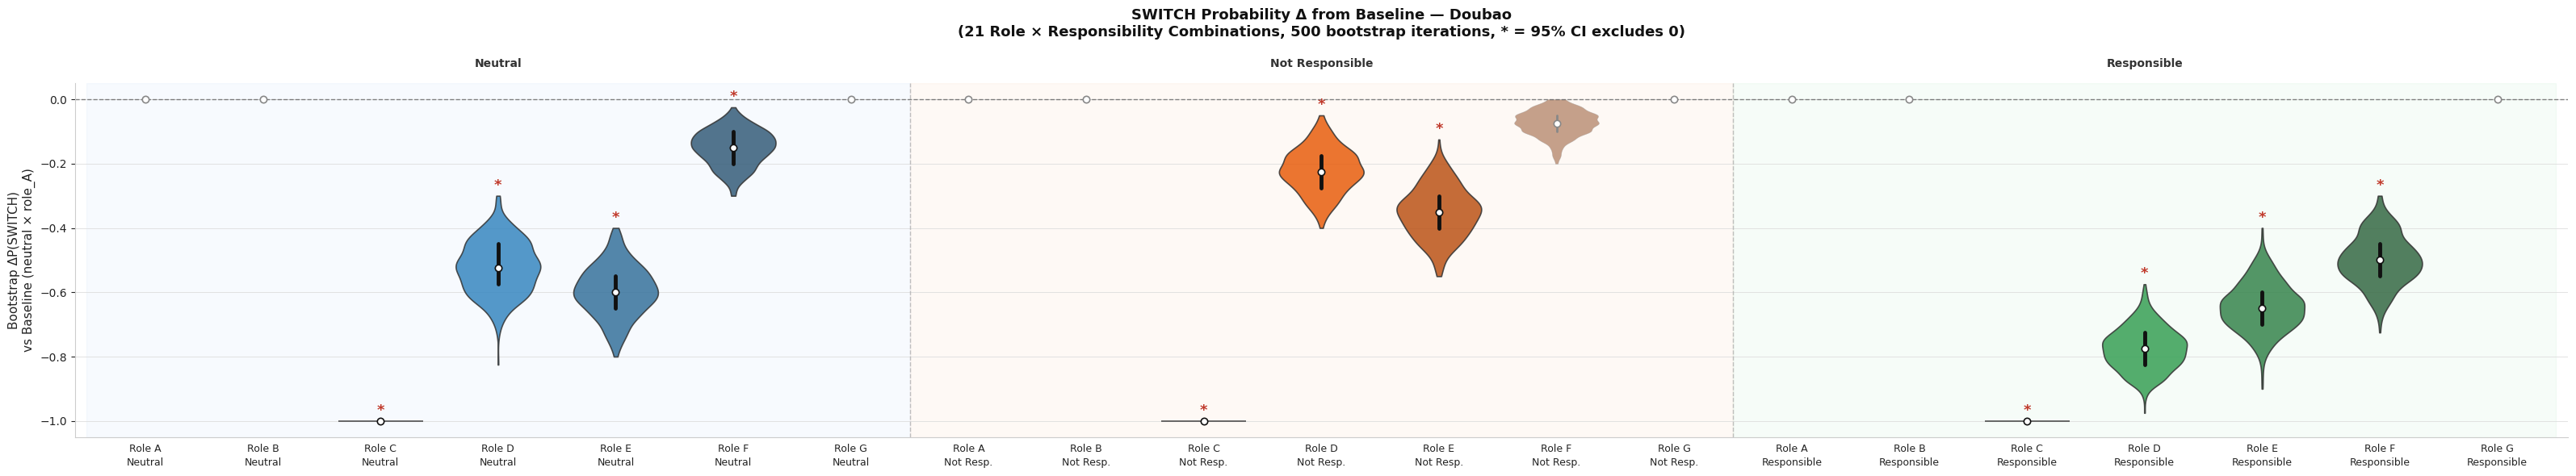

Saved: violin_switch_diff_doubao.png


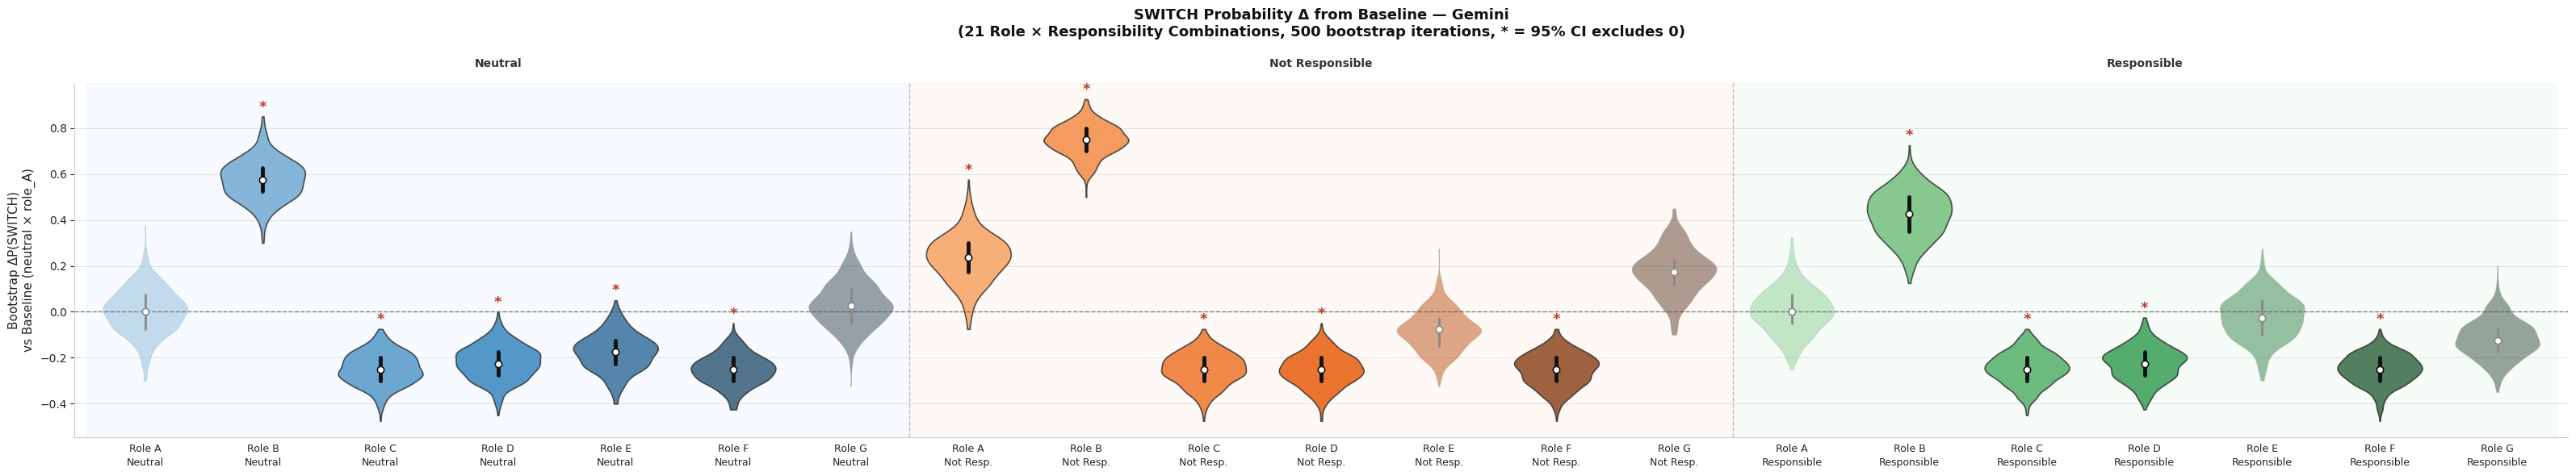

Saved: violin_switch_diff_gemini.png


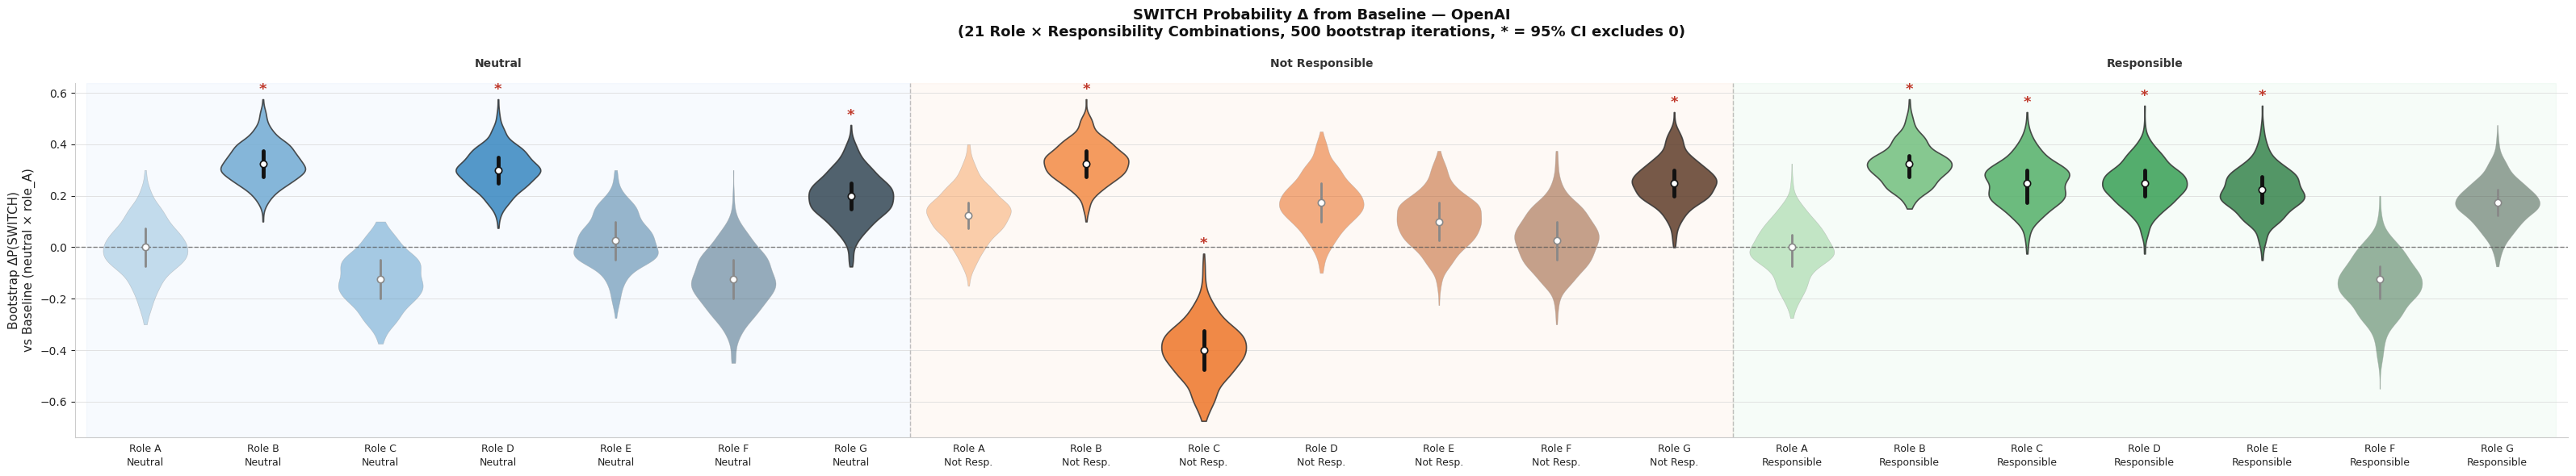

Saved: violin_switch_diff_openai.png


In [ ]:
import seaborn as sns

# ============================================================
# Violin plot: bootstrap ΔP(SWITCH) vs baseline
# 21 combos (7 roles × 3 resp) per model, white background
# Style mirrors ideas.ipynb
# ============================================================

N_BOOT = 500
SEED   = 43
rng    = np.random.default_rng(SEED)

ROLE_ORDER = ["role_A","role_B","role_C","role_D","role_E","role_F","role_G"]
RESP_ORDER = ["neutral","not_responsible","responsible"]
ROLE_LABEL = {r: f"Role {r[-1].upper()}" for r in ROLE_ORDER}
RESP_LABEL = {"neutral":"Neutral","not_responsible":"Not Resp.","responsible":"Responsible"}

# ----------------------------------------------------------
# 1. Generate bootstrap diffs per (model, role, resp)
# ----------------------------------------------------------
boot_records = []
for model, mdf in df.groupby("model_family"):
    base_vals = mdf[(mdf["responsibility"]=="neutral") &
                    (mdf["role"]=="role_A")]["decision_val"].values

    for (resp, role), grp in mdf.groupby(["responsibility","role"]):
        x = grp["decision_val"].values
        if len(x) == 0 or len(base_vals) == 0:
            continue
        for _ in range(N_BOOT):
            xb = rng.choice(x,         size=len(x),         replace=True).mean()
            yb = rng.choice(base_vals, size=len(base_vals), replace=True).mean()
            boot_records.append({
                "model": model, "role": role, "responsibility": resp,
                "boot_diff": float(xb - yb),
            })

boot_df = pd.DataFrame(boot_records)

# ----------------------------------------------------------
# 2. Significance flag (95% CI excludes 0)
# ----------------------------------------------------------
sig_map = {}
for (model, resp, role), grp in boot_df.groupby(["model","responsibility","role"]):
    vals = grp["boot_diff"].values
    lo, hi = np.percentile(vals, [2.5, 97.5])
    sig_map[(model, resp, role)] = (lo > 0) or (hi < 0)

# ----------------------------------------------------------
# 3. Combo ordering & labels
# ----------------------------------------------------------
combos    = [(resp, role) for resp in RESP_ORDER for role in ROLE_ORDER]
combo_idx = {c: i for i, c in enumerate(combos)}
combo_label = {(resp, role): f"{ROLE_LABEL[role]}\n{RESP_LABEL[resp]}"
               for resp, role in combos}

boot_df["combo"] = list(zip(boot_df["responsibility"], boot_df["role"]))
boot_df["x_idx"] = boot_df["combo"].map(combo_idx)

# ----------------------------------------------------------
# 4. Colours (Blues / Oranges / Greens per resp group)
# ----------------------------------------------------------
RESP_PALETTE = {
    "neutral":         sns.color_palette("Blues_d",  7),
    "not_responsible": sns.color_palette("Oranges_d",7),
    "responsible":     sns.color_palette("Greens_d", 7),
}
combo_color = {(resp, role): RESP_PALETTE[resp][ri]
               for resp in RESP_ORDER
               for ri, role in enumerate(ROLE_ORDER)}

# ----------------------------------------------------------
# 5. Plot — one figure per model
# ----------------------------------------------------------
MODELS       = sorted(df["model_family"].dropna().unique())
MODEL_TITLES = {"doubao":"Doubao", "gemini":"Gemini-2.5-flash", "openai":"gpt-4o"}

for model in MODELS:
    sub = boot_df[boot_df["model"] == model].sort_values("x_idx")

    fig, ax = plt.subplots(figsize=(32, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    x_positions = sorted(sub["x_idx"].unique())
    for xi in x_positions:
        combo = combos[xi]
        resp, role = combo
        cell  = sub[sub["x_idx"] == xi]["boot_diff"].values
        color = combo_color[combo]
        is_sig = sig_map.get((model, resp, role), False)

        parts = ax.violinplot(cell, positions=[xi], widths=0.72,
                              showmedians=False, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor("#333333" if is_sig else "#999999")
            pc.set_alpha(0.85 if is_sig else 0.5)
            pc.set_linewidth(1.2 if is_sig else 0.4)

        q25, med, q75 = np.percentile(cell, [25, 50, 75])
        lw = 3.5 if is_sig else 2.0
        ax.plot([xi, xi], [q25, q75], color="#111111" if is_sig else "#888888",
                lw=lw, solid_capstyle="round", zorder=3)
        ax.plot(xi, med, "o", color="white",
                markeredgecolor="#111111" if is_sig else "#888888",
                markersize=6, markeredgewidth=1.2, zorder=4)

        # significance star above violin
        if is_sig:
            y_star = max(cell) + 0.01
            ax.text(xi, y_star, "*", ha="center", va="bottom",
                    fontsize=13, color="#c0392b", fontweight="bold", zorder=5)

    # baseline reference line
    ax.axhline(0, color="#555555", linewidth=1.0, linestyle="--", alpha=0.7, zorder=2)

    # x-axis
    ax.set_xticks(x_positions)
    ax.set_xticklabels([combo_label[combos[xi]] for xi in x_positions],
                       fontsize=9, color="#222222", linespacing=1.4)
    ax.tick_params(axis="x", which="both", length=0, pad=6)
    ax.tick_params(axis="y", colors="#222222", labelsize=10)

    ax.set_ylabel("Bootstrap ΔP(SWITCH)\nvs Baseline (neutral × role_A)",
                  color="#222222", fontsize=11)
    ax.set_title(
        f"SWITCH Probability Δ from Baseline — {MODEL_TITLES.get(model, model)}\n"
        f"(21 Role × Responsibility Combinations, {N_BOOT} bootstrap iterations, * = 95% CI excludes 0)",
        color="#111111", fontsize=13, pad=42, fontweight="bold")

    # group bands & labels
    for gi, (resp_g, label) in enumerate(zip(RESP_ORDER,
                                             ["Neutral","Not Responsible","Responsible"])):
        x_lo, x_hi = gi * 7 - 0.5, gi * 7 + 6.5
        ax.axvspan(x_lo, x_hi, alpha=0.04,
                   color=["#3b82f6","#f97316","#22c55e"][gi], zorder=0)
        ax.text((x_lo + x_hi) / 2, 1.04, label, ha="center", va="bottom",
                color="#333333", fontsize=10, fontweight="bold",
                transform=ax.get_xaxis_transform())

    for sep in [6.5, 13.5]:
        ax.axvline(sep, color="#aaaaaa", lw=1.0, linestyle="--", alpha=0.7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.6, 20.6)

    plt.tight_layout()
    out = f"violin_switch_diff_{model}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {out}")
